                   S&P Spot 1193 type     expiry       K  PX_BID  PX_ASK  \
0   SPXQ US 03/30/12 C1350 Index    C 2012-03-30  1350.0    17.2    18.7   
1   SPXQ US 03/30/12 C1400 Index    C 2012-03-30  1400.0     7.8     9.4   
2   SPXQ US 03/30/12 P1100 Index    P 2012-03-30  1100.0    55.2    57.2   
3   SPXQ US 03/30/12 P1200 Index    P 2012-03-30  1200.0    90.6    93.1   
4    SPXQ US 03/30/12 P800 Index    P 2012-03-30   800.0     9.8    11.3   
5    SPX US 06/16/12 C1175 Index    C 2012-06-16  1175.0   109.6   113.1   
6    SPX US 06/16/12 C1200 Index    C 2012-06-16  1200.0    95.4    98.8   
7    SPX US 06/16/12 P1175 Index    P 2012-06-16  1175.0   102.7   106.3   
8    SPX US 06/16/12 P1200 Index    P 2012-06-16  1200.0   113.4   117.2   
9    SPX US 06/16/12 P1225 Index    P 2012-06-16  1225.0   124.9   128.6   
10   SPX US 09/22/12 C1175 Index    C 2012-09-22  1175.0   127.2   131.0   
11   SPX US 09/22/12 C1200 Index    C 2012-09-22  1200.0   113.1   117.0   
12   SPX US 

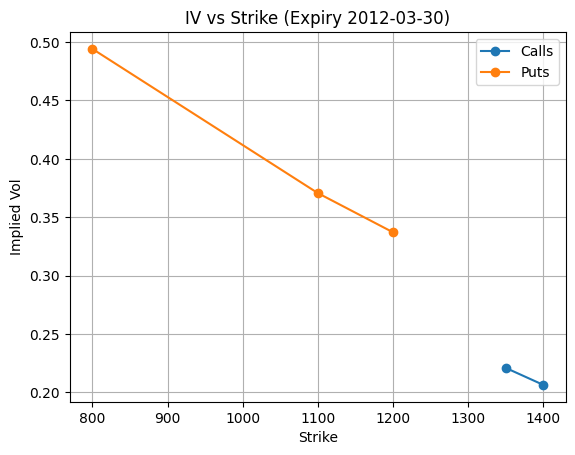

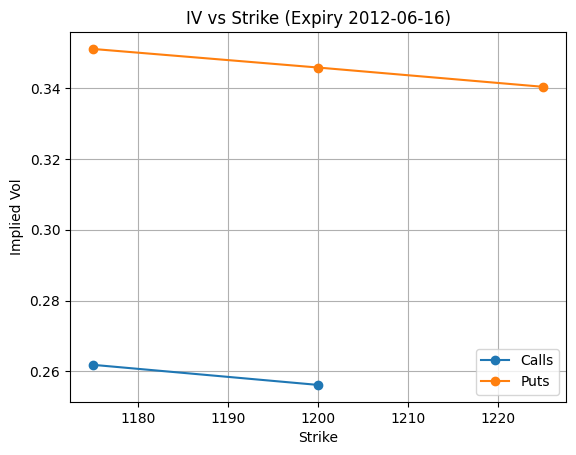

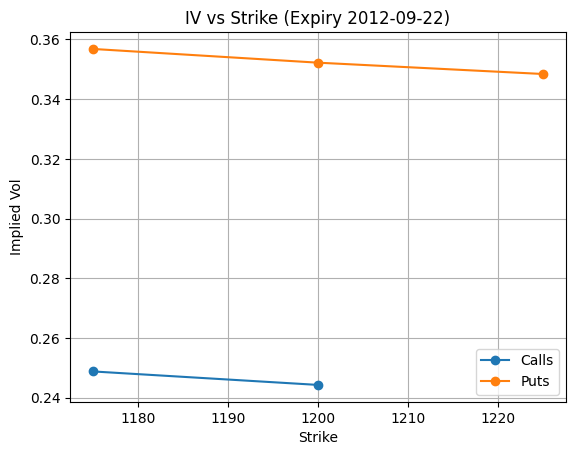

In [5]:
import math
import re
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt

# we assume r=q=0
FILE_PATH = "SPX_OptionPrices_11.21.2011.csv"
TRADE_DATE = datetime(2011, 11, 21)
r = 0.05
q = 0.02


# Normal CDF
def N(x):
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))


# Black–Scholes prices
def call_price(S, K, r, q, sigma, T):
    d1 = (math.log(S / K) + (r - q + 0.5 * sigma * sigma) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return S * math.exp(-q * T) * N(d1) - K * math.exp(-r * T) * N(d2)

def put_price(S, K, r, q, sigma, T):
    d1 = (math.log(S / K) + (r - q + 0.5 * sigma * sigma) * T) / (sigma * math.sqrt(T))
    d2 = d1 - sigma * math.sqrt(T)
    return K * math.exp(-r * T) * N(-d2) - S * math.exp(-q * T) * N(-d1)


# ----------------------------
# Implied vol by using bisection
def implied_vol(mid, S, K, r, q, T, opt_type):
    if mid <= 0 or T <= 0:
        return float("nan")

    price_fn = call_price if opt_type == "C" else put_price

    low = 1e-6
    high = 5.0

    f_low = price_fn(S, K, r, q, low, T) - mid
    f_high = price_fn(S, K, r, q, high, T) - mid

    if f_low * f_high > 0:
        return float("nan")  # couldn't bracket

    for _ in range(120):
        mid_sigma = 0.5 * (low + high)
        f_mid = price_fn(S, K, r, q, mid_sigma, T) - mid

        if abs(f_mid) < 1e-10:
            return mid_sigma

        if f_low * f_mid <= 0:
            high = mid_sigma
            f_high = f_mid
        else:
            low = mid_sigma
            f_low = f_mid

    return 0.5 * (low + high)



df = pd.read_excel(FILE_PATH, sheet_name="Copy")

# Spot is in the first column header: "S&P Spot 1193"
first_col = df.columns[0]
m = re.search(r"(\d+(\.\d+)?)", str(first_col))
S0 = float(m.group(1))

# Parse expiry + type from the option description string in the first column
def parse_expiry_and_type(text):
    text = str(text)

    d = re.search(r"(\d{2}/\d{2}/\d{2})", text)
    expiry = datetime.strptime(d.group(1), "%m/%d/%y")

    t = re.search(r"\s([CP])\d+", text)
    opt_type = t.group(1)

    return expiry, opt_type

df["expiry"], df["type"] = zip(*df[first_col].map(parse_expiry_and_type))

df["T"] = (df["expiry"] - TRADE_DATE).dt.days / 365.0
df["K"] = df["OPT_STRIKE_PX"].astype(float)
df["mid"] = 0.5 * (df["PX_BID"] + df["PX_ASK"])

# Compute IVs
df["iv"] = df.apply(lambda row: implied_vol(row["mid"], S0, row["K"], r, q, row["T"], row["type"]), axis=1)

print(df[[first_col, "type", "expiry", "K", "PX_BID", "PX_ASK", "mid", "T", "iv"]])


# (ii) Plot IV vs strike by expiry
for expiry, sub in df.groupby("expiry"):
    sub = sub.sort_values("K")
    calls = sub[sub["type"] == "C"]
    puts = sub[sub["type"] == "P"]

    plt.figure()
    if len(calls) > 0:
        plt.plot(calls["K"], calls["iv"], marker="o", label="Calls")
    if len(puts) > 0:
        plt.plot(puts["K"], puts["iv"], marker="o", label="Puts")

    plt.title(f"IV vs Strike (Expiry {expiry.date()})")
    plt.xlabel("Strike")
    plt.ylabel("Implied Vol")
    plt.grid(True)
    plt.legend()
    plt.show()